<a href="https://colab.research.google.com/github/eceguner12/DATS501/blob/main/DATS501_XGBoost_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATS 501 - Final Assignment
## Predicting Income Bracket with XGBoost (U.S. Adult Census Income)

This notebook implements the full supervised-learning pipeline used in the lab report:


### 1. Load data from Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# '?' is the missing-value placeholder in this dataset
df = pd.read_csv('/content/drive/MyDrive/adult.csv', na_values=['?'])
print("Shape:", df.shape)
df.head()


Mounted at /content/drive
Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2. Descriptive overview

In [2]:
print(df.describe().round(2).T)
print("\nTarget balance:")
print(df['income'].value_counts())
print((df['income'].value_counts(normalize=True)*100).round(2))


                  count       mean        std      min       25%       50%  \
age             32561.0      38.58      13.64     17.0      28.0      37.0   
fnlwgt          32561.0  189778.37  105549.98  12285.0  117827.0  178356.0   
education.num   32561.0      10.08       2.57      1.0       9.0      10.0   
capital.gain    32561.0    1077.65    7385.29      0.0       0.0       0.0   
capital.loss    32561.0      87.30     402.96      0.0       0.0       0.0   
hours.per.week  32561.0      40.44      12.35      1.0      40.0      40.0   

                     75%        max  
age                 48.0       90.0  
fnlwgt          237051.0  1484705.0  
education.num       12.0       16.0  
capital.gain         0.0    99999.0  
capital.loss         0.0     4356.0  
hours.per.week      45.0       99.0  

Target balance:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


In [3]:
missing = df.isnull().sum()
print("Missing per column:\n", missing[missing>0])
print("\nRows with >=1 missing:", df.isnull().any(axis=1).sum(),
      f"({df.isnull().any(axis=1).mean()*100:.2f}%)")


Missing per column:
 workclass         1836
occupation        1843
native.country     583
dtype: int64

Rows with >=1 missing: 2399 (7.37%)


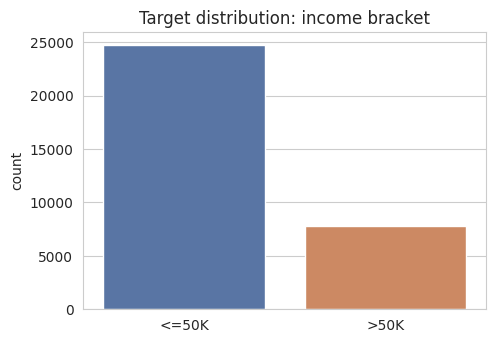

In [4]:
plt.figure(figsize=(5.2,3.6))
sns.countplot(x='income', data=df, hue='income', palette=['#4C72B0','#DD8452'], legend=False)
plt.title('Target distribution: income bracket'); plt.xlabel(''); plt.show()


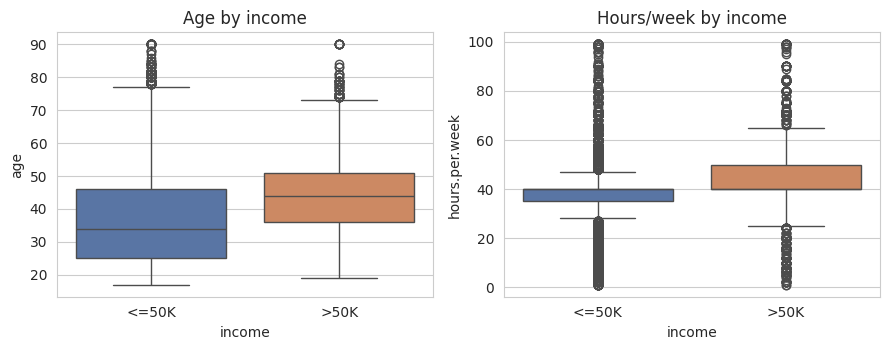

In [5]:
fig, ax = plt.subplots(1,2, figsize=(9,3.6))
sns.boxplot(x='income', y='age', data=df, hue='income', palette=['#4C72B0','#DD8452'], legend=False, ax=ax[0]); ax[0].set_title('Age by income')
sns.boxplot(x='income', y='hours.per.week', data=df, hue='income', palette=['#4C72B0','#DD8452'], legend=False, ax=ax[1]); ax[1].set_title('Hours/week by income')
plt.tight_layout(); plt.show()


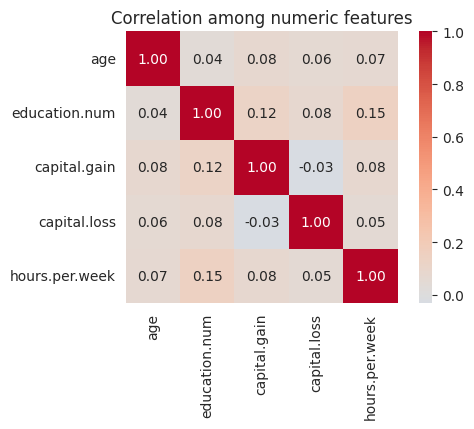

In [6]:
num_cols = ['age','education.num','capital.gain','capital.loss','hours.per.week']
plt.figure(figsize=(5.6,4.4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation among numeric features'); plt.tight_layout(); plt.show()


### 3. Data preparation
**Missing values:** mode imputation for the three categorical columns.  


In [7]:
for col in ['workclass','occupation','native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Total missing after imputation:", df.isnull().sum().sum())


Total missing after imputation: 0


In [8]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
cat_cols = [c for c in df_enc.select_dtypes(include='object').columns if c != 'income']
for c in cat_cols:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

y = (df_enc['income'].str.strip() == '>50K').astype(int)
X = df_enc.drop(columns=['income'])
print('Features:', X.shape, '| Positive rate:', round(y.mean(),4))


Features: (32561, 14) | Positive rate: 0.2408


In [9]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (26048, 14) | Test: (6513, 14)


### 4. Train the XGBoost classifier


In [10]:
from xgboost import XGBClassifier
spw = (y_train==0).sum() / (y_train==1).sum()

model = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric='logloss',
    random_state=RANDOM_STATE)
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

### 5. Evaluation

In [11]:
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['<=50K','>50K']))


Accuracy : 0.8359
ROC-AUC  : 0.9206

              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.89      4945
        >50K       0.62      0.82      0.71      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.83      0.80      6513
weighted avg       0.86      0.84      0.84      6513



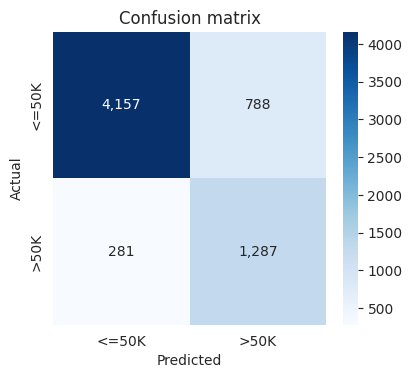

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.4,3.8))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix'); plt.show()


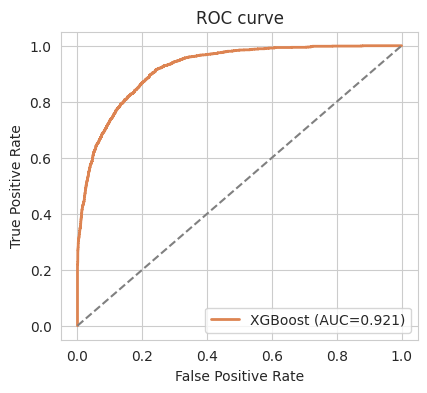

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(4.6,4.0))
plt.plot(fpr, tpr, color='#DD8452', lw=2, label=f'XGBoost (AUC={roc_auc_score(y_test,y_proba):.3f})')
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC curve'); plt.legend(); plt.show()


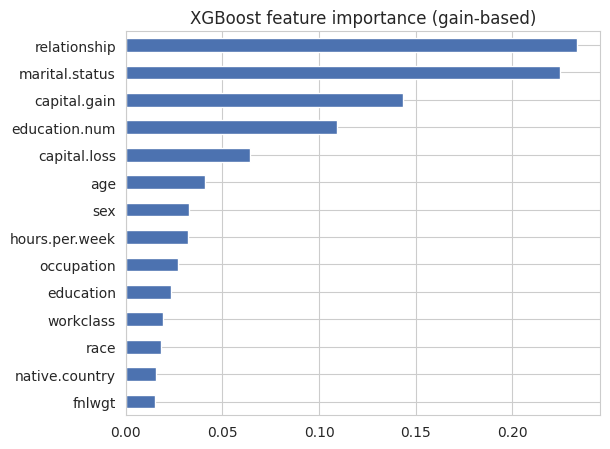

In [14]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(6.2,4.6))
imp.plot(kind='barh', color='#4C72B0')
plt.title('XGBoost feature importance (gain-based)'); plt.tight_layout(); plt.show()
